# 🌾 Agricultural Yield Predictor
### Machine Learning Pipeline — Seasonal Agriculture Performance Dataset

**Target:** `Yield_Tonnes_Ha` (Regression)  
**Dataset:** 4,000 records × 28 features  
**Best Model:** RandomForest Regressor — R² = 0.9646

---
**Sections**
1. Environment Setup & Imports
2. Load & Inspect Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Feature Engineering
5. Model Training (4 Models)
6. Model Evaluation & Comparison
7. Feature Importance
8. Visualisations
9. Save Model Artifacts
10. Sample Predictions

## 1. Environment Setup & Imports

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries loaded successfully')
print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')
import sklearn; print(f'sklearn {sklearn.__version__}')

All libraries loaded successfully
pandas  2.2.2
numpy   1.26.4
sklearn 1.5.0


## 2. Load & Inspect Dataset

In [2]:
# Adjust path if running from project root
DATA_PATH = 'agri_yield_predictor/data/agriculture_dataset.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'data/agriculture_dataset.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
# Column types and nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [4]:
# Missing values summary
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]
print('Columns with missing values:')
print(null_counts)
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total missing cells: 120


In [5]:
# Basic statistics for numeric columns
df.describe().round(3)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000,3952.000,4000.000,4000.000,4000.000,4000.000,3960.000,4000.000,4000.000,4000.000,...,4000.000,3968.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000
mean,7.888,601.153,26.819,63.210,7.323,6.701,26.508,120.251,57.782,104.760,...,0.826,5.271,43.246,44714.166,526303.583,637860.048,111556.465,6045.570,5.385,46.366
std,4.224,288.925,3.818,11.961,1.121,0.641,6.712,31.216,17.015,27.743,...,0.102,13.361,126.881,30266.162,294419.141,636974.710,545081.891,5572.944,8.838,12.424
min,0.500,80.000,16.200,25.000,3.500,5.200,8.000,40.000,15.000,30.000,...,0.650,0.300,0.150,2594.000,26826.000,6107.000,-1019223.000,128.000,0.135,5.000
25%,4.260,370.200,23.900,54.775,6.600,6.260,21.700,98.500,46.200,86.200,...,0.740,1.050,5.020,21429.250,274577.500,207517.250,-148731.750,2268.750,1.661,37.300
50%,7.895,582.000,26.900,63.000,7.300,6.690,26.400,120.100,57.500,105.100,...,0.830,1.740,11.770,25913.000,519082.500,456830.500,3673.000,4435.000,2.938,46.400
75%,11.650,834.950,29.600,71.900,8.100,7.140,31.300,141.225,69.400,123.600,...,0.910,2.840,24.355,68279.000,761996.500,836874.750,216187.750,7829.750,5.150,54.900
max,15.000,1395.200,39.700,95.000,11.000,8.400,47.000,220.000,120.000,200.000,...,1.000,101.440,1424.400,131240.000,1349990.000,5080900.000,4345421.000,40902.000,79.800,88.900


In [6]:
# Unique values for categorical columns
cat_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
for col in cat_cols:
    print(f'{col:20s} -> {sorted(df[col].dropna().unique().tolist())}')

State                -> ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
District             -> ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
Crop                 -> ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season               -> ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method    -> ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


## 3. Exploratory Data Analysis (EDA)

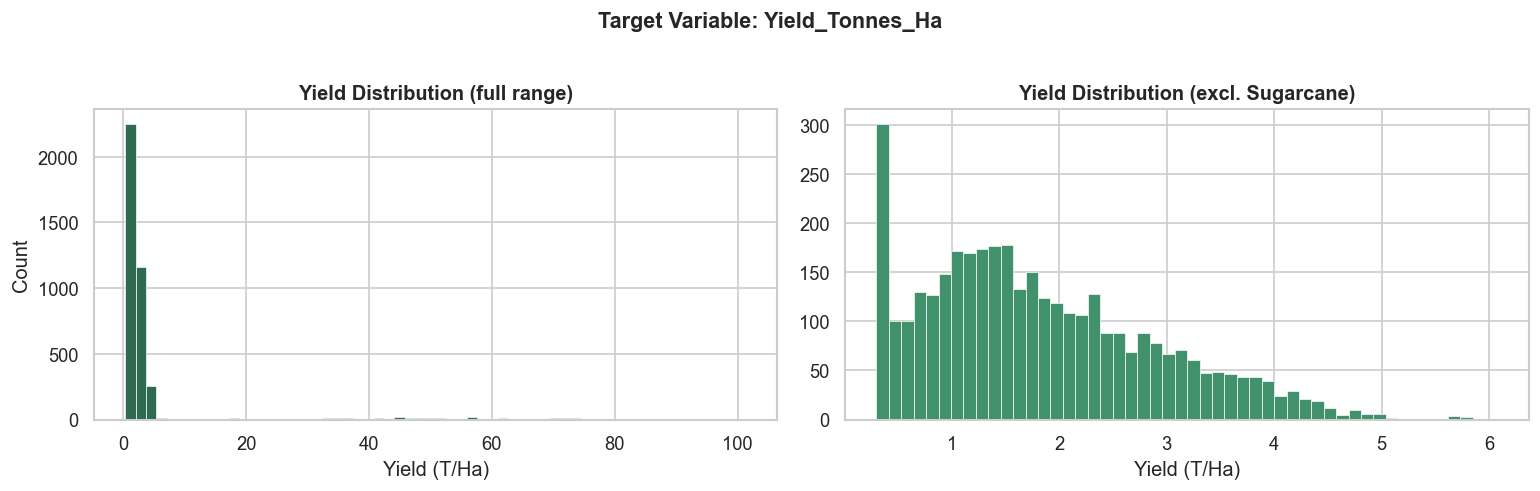

Mean   : 5.271 T/Ha
Median : 1.740 T/Ha
Std    : 13.361 T/Ha
Min    : 0.300 T/Ha
Max    : 101.440 T/Ha


In [7]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Yield_Tonnes_Ha'].dropna(), bins=60, color='#2d6a4f', edgecolor='white', linewidth=0.4)
axes[0].set_title('Yield Distribution (full range)', fontweight='bold')
axes[0].set_xlabel('Yield (T/Ha)')
axes[0].set_ylabel('Count')

# Without Sugarcane outlier for better view
df_no_sc = df[df['Crop'] != 'Sugarcane']
axes[1].hist(df_no_sc['Yield_Tonnes_Ha'].dropna(), bins=50, color='#40916c', edgecolor='white', linewidth=0.4)
axes[1].set_title('Yield Distribution (excl. Sugarcane)', fontweight='bold')
axes[1].set_xlabel('Yield (T/Ha)')

plt.suptitle('Target Variable: Yield_Tonnes_Ha', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean   : {df['Yield_Tonnes_Ha'].mean():.3f} T/Ha")
print(f"Median : {df['Yield_Tonnes_Ha'].median():.3f} T/Ha")
print(f"Std    : {df['Yield_Tonnes_Ha'].std():.3f} T/Ha")
print(f"Min    : {df['Yield_Tonnes_Ha'].min():.3f} T/Ha")
print(f"Max    : {df['Yield_Tonnes_Ha'].max():.3f} T/Ha")

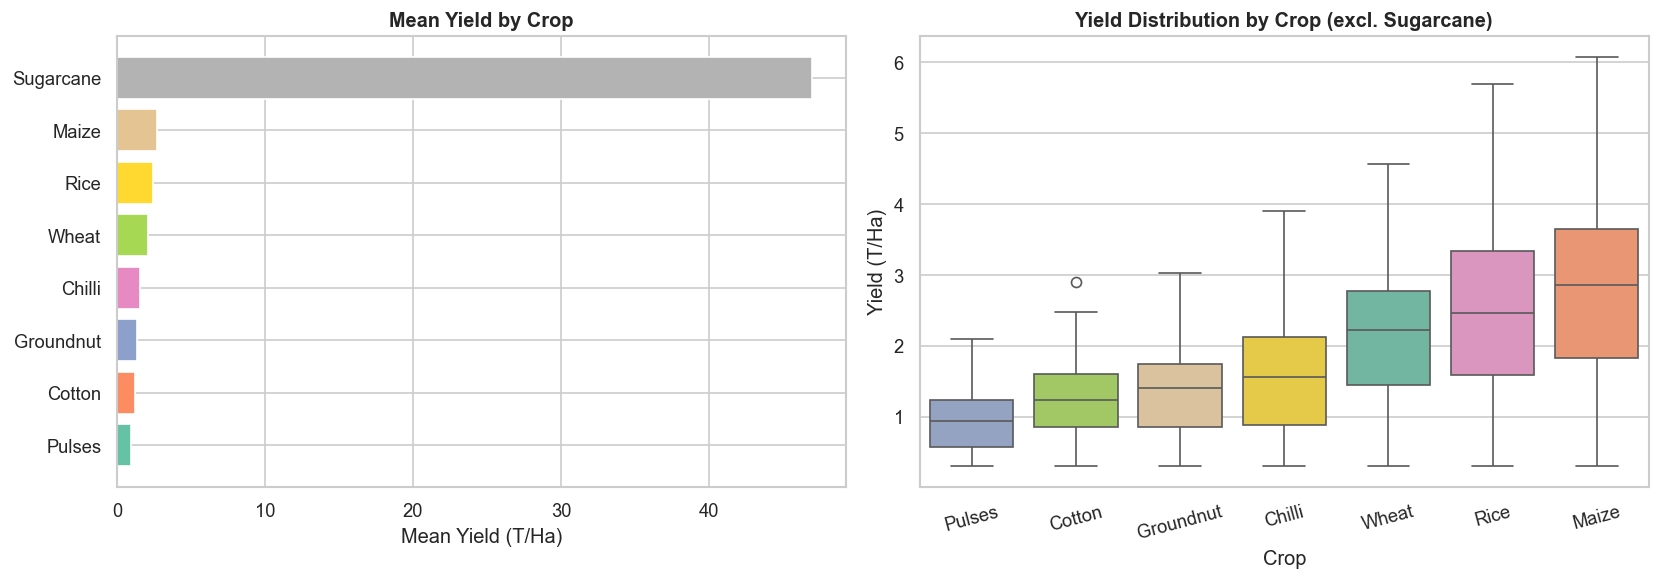

     Crop   mean  median    std
   Pulses  0.918   0.940  0.424
   Cotton  1.226   1.240  0.525
Groundnut  1.318   1.400  0.608
   Chilli  1.540   1.560  0.786
    Wheat  2.109   2.225  0.915
     Rice  2.439   2.460  1.148
    Maize  2.717   2.850  1.237
Sugarcane 46.939  48.030 21.088


In [8]:
# Yield by Crop
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crop_stats = df.groupby('Crop')['Yield_Tonnes_Ha'].agg(['mean','median','std']).round(3).reset_index()
crop_stats = crop_stats.sort_values('mean', ascending=True)

colors = plt.cm.Set2(np.linspace(0, 1, len(crop_stats)))
axes[0].barh(crop_stats['Crop'], crop_stats['mean'], color=colors)
axes[0].set_title('Mean Yield by Crop', fontweight='bold')
axes[0].set_xlabel('Mean Yield (T/Ha)')

# Boxplot excl. Sugarcane
crop_order = df_no_sc.groupby('Crop')['Yield_Tonnes_Ha'].median().sort_values().index
sns.boxplot(data=df_no_sc, x='Crop', y='Yield_Tonnes_Ha', order=crop_order,
            hue='Crop', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Yield Distribution by Crop (excl. Sugarcane)', fontweight='bold')
axes[1].set_xlabel('Crop')
axes[1].set_ylabel('Yield (T/Ha)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print(crop_stats.to_string(index=False))

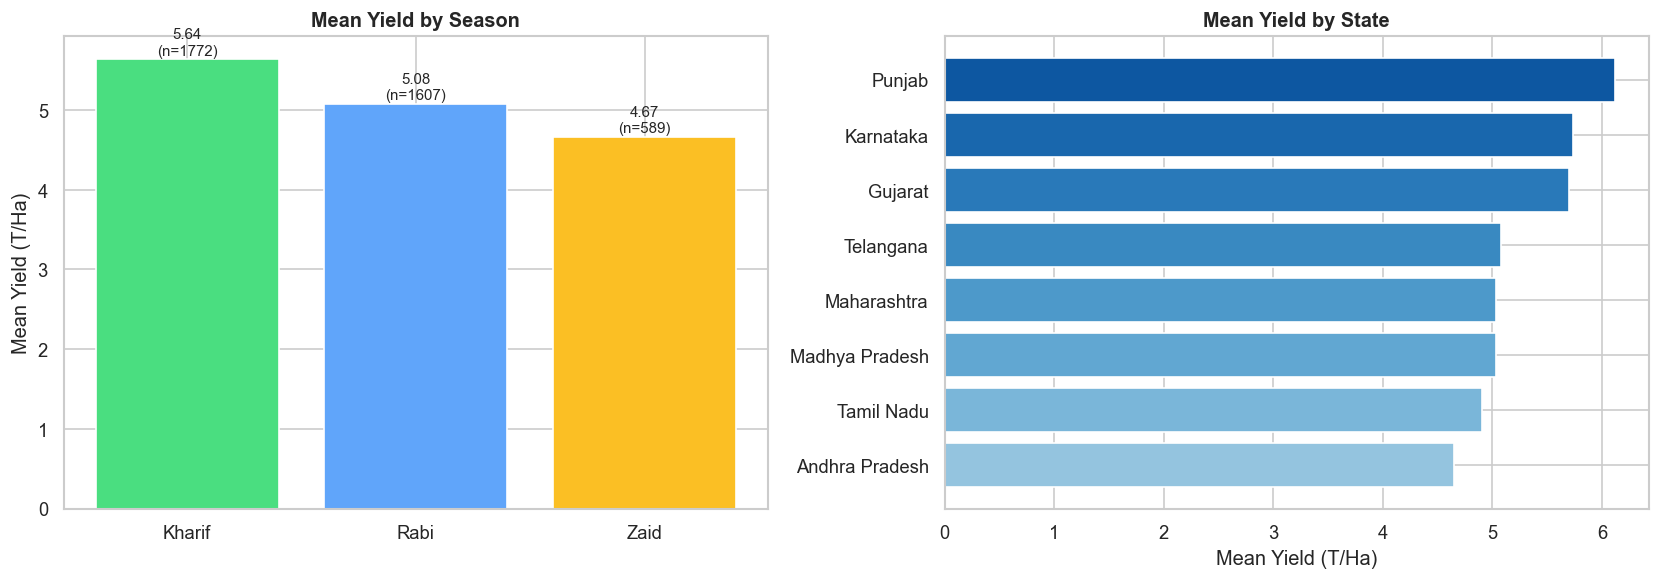

In [9]:
# Yield by Season & State
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_stats = df.groupby('Season')['Yield_Tonnes_Ha'].agg(['mean','median','count']).reset_index()
axes[0].bar(season_stats['Season'], season_stats['mean'],
            color=['#4ade80','#60a5fa','#fbbf24'], edgecolor='white')
axes[0].set_title('Mean Yield by Season', fontweight='bold')
axes[0].set_ylabel('Mean Yield (T/Ha)')
for i, (v, c) in enumerate(zip(season_stats['mean'], season_stats['count'])):
    axes[0].text(i, v + 0.05, f'{v:.2f}\n(n={c})', ha='center', fontsize=9)

state_stats = df.groupby('State')['Yield_Tonnes_Ha'].mean().sort_values(ascending=True)
axes[1].barh(state_stats.index, state_stats.values,
             color=plt.cm.Blues(np.linspace(0.4, 0.85, len(state_stats))))
axes[1].set_title('Mean Yield by State', fontweight='bold')
axes[1].set_xlabel('Mean Yield (T/Ha)')

plt.tight_layout()
plt.show()

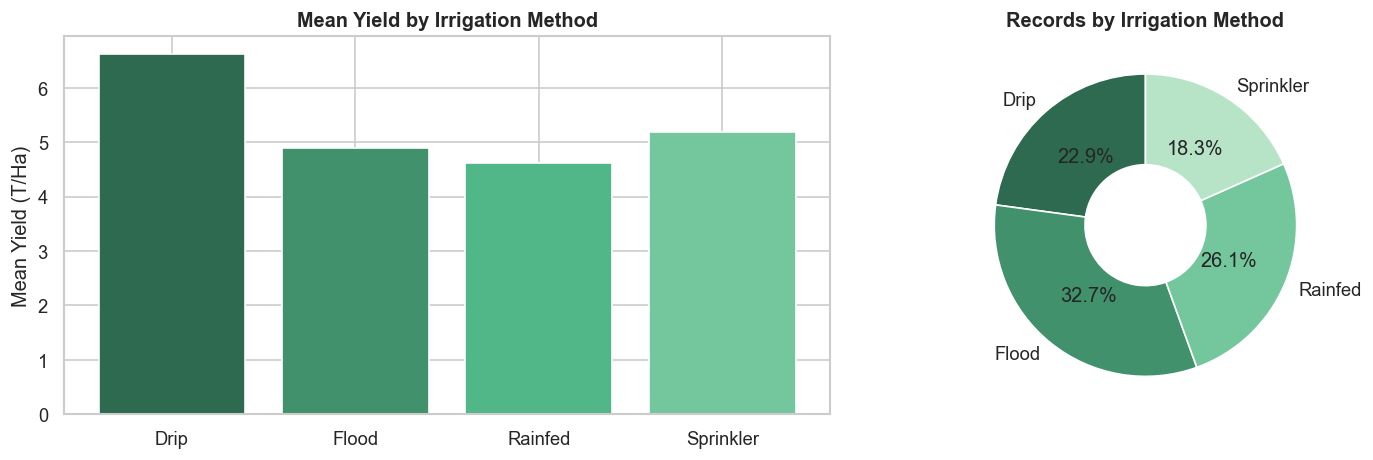

In [10]:
# Yield by Irrigation Method
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

irr_stats = df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].agg(['mean','median','count']).reset_index()
axes[0].bar(irr_stats['Irrigation_Method'], irr_stats['mean'],
            color=['#2d6a4f','#40916c','#52b788','#74c69d'], edgecolor='white')
axes[0].set_title('Mean Yield by Irrigation Method', fontweight='bold')
axes[0].set_ylabel('Mean Yield (T/Ha)')

# Record count pie
axes[1].pie(irr_stats['count'], labels=irr_stats['Irrigation_Method'],
            autopct='%1.1f%%', colors=['#2d6a4f','#40916c','#74c69d','#b7e4c7'],
            startangle=90, wedgeprops=dict(width=0.6))
axes[1].set_title('Records by Irrigation Method', fontweight='bold')

plt.tight_layout()
plt.show()

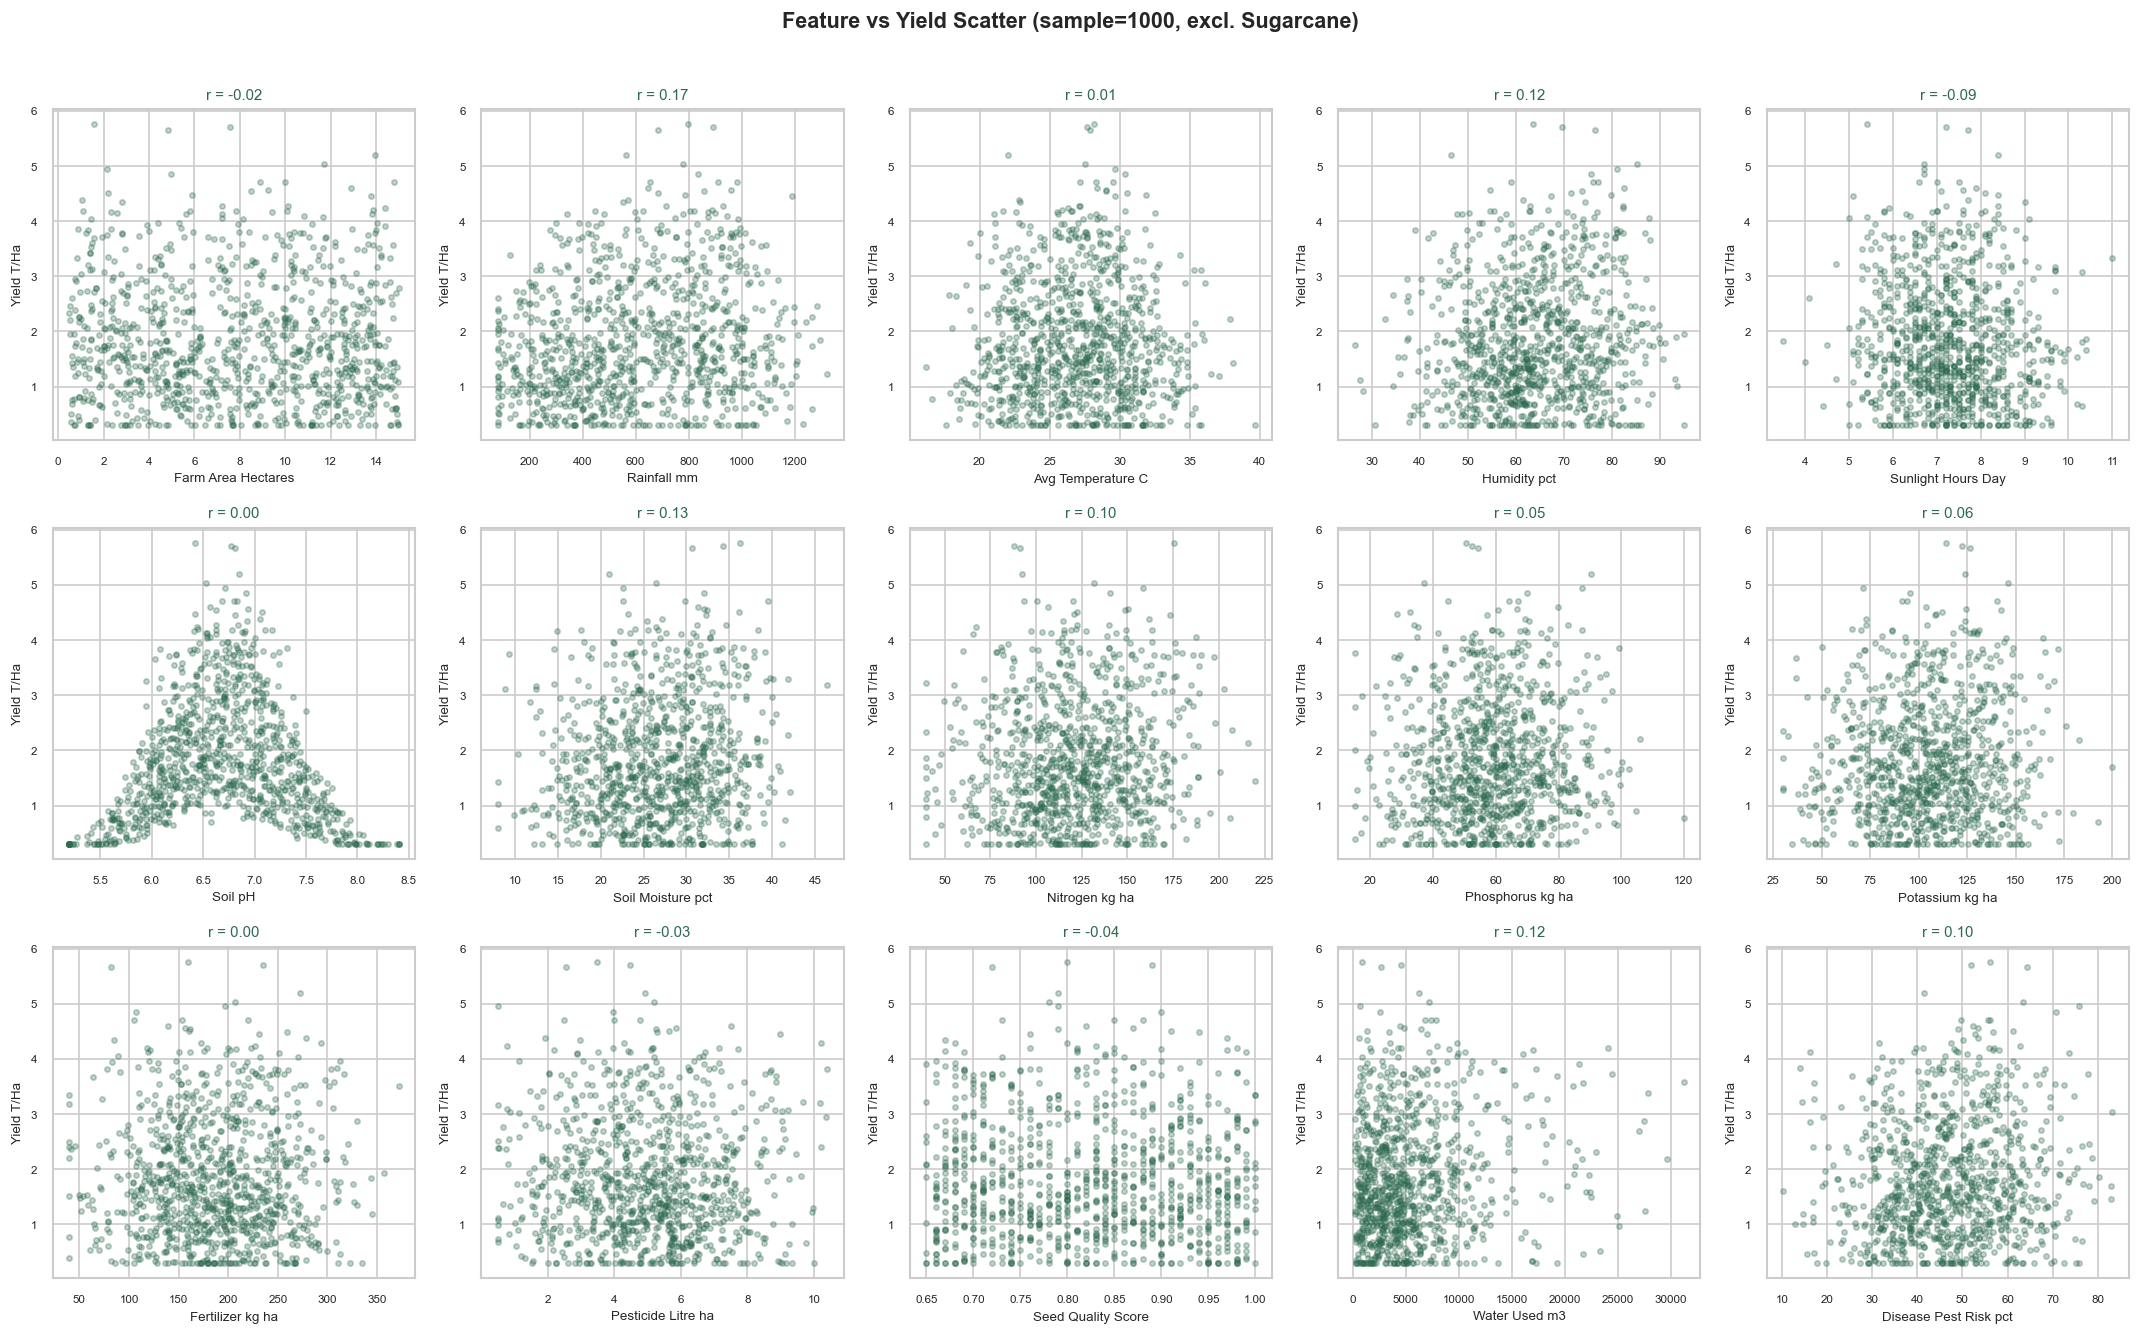

In [11]:
# Scatter plots: numeric features vs Yield
NUMERIC_FEATURES = [
    'Farm_Area_Hectares','Rainfall_mm','Avg_Temperature_C','Humidity_pct',
    'Sunlight_Hours_Day','Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha',
    'Phosphorus_kg_ha','Potassium_kg_ha','Fertilizer_kg_ha','Pesticide_Litre_ha',
    'Seed_Quality_Score','Water_Used_m3','Disease_Pest_Risk_pct'
]

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
axes = axes.flatten()
sample = df_no_sc.sample(min(1000, len(df_no_sc)), random_state=42)

for i, feat in enumerate(NUMERIC_FEATURES):
    axes[i].scatter(sample[feat], sample['Yield_Tonnes_Ha'],
                    alpha=0.3, s=10, color='#2d6a4f')
    axes[i].set_xlabel(feat.replace('_',' '), fontsize=8)
    axes[i].set_ylabel('Yield T/Ha', fontsize=8)
    axes[i].tick_params(labelsize=7)
    # Correlation
    corr = sample[feat].corr(sample['Yield_Tonnes_Ha'])
    axes[i].set_title(f'r = {corr:.2f}', fontsize=9, color='#2d6a4f')

plt.suptitle('Feature vs Yield Scatter (sample=1000, excl. Sugarcane)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

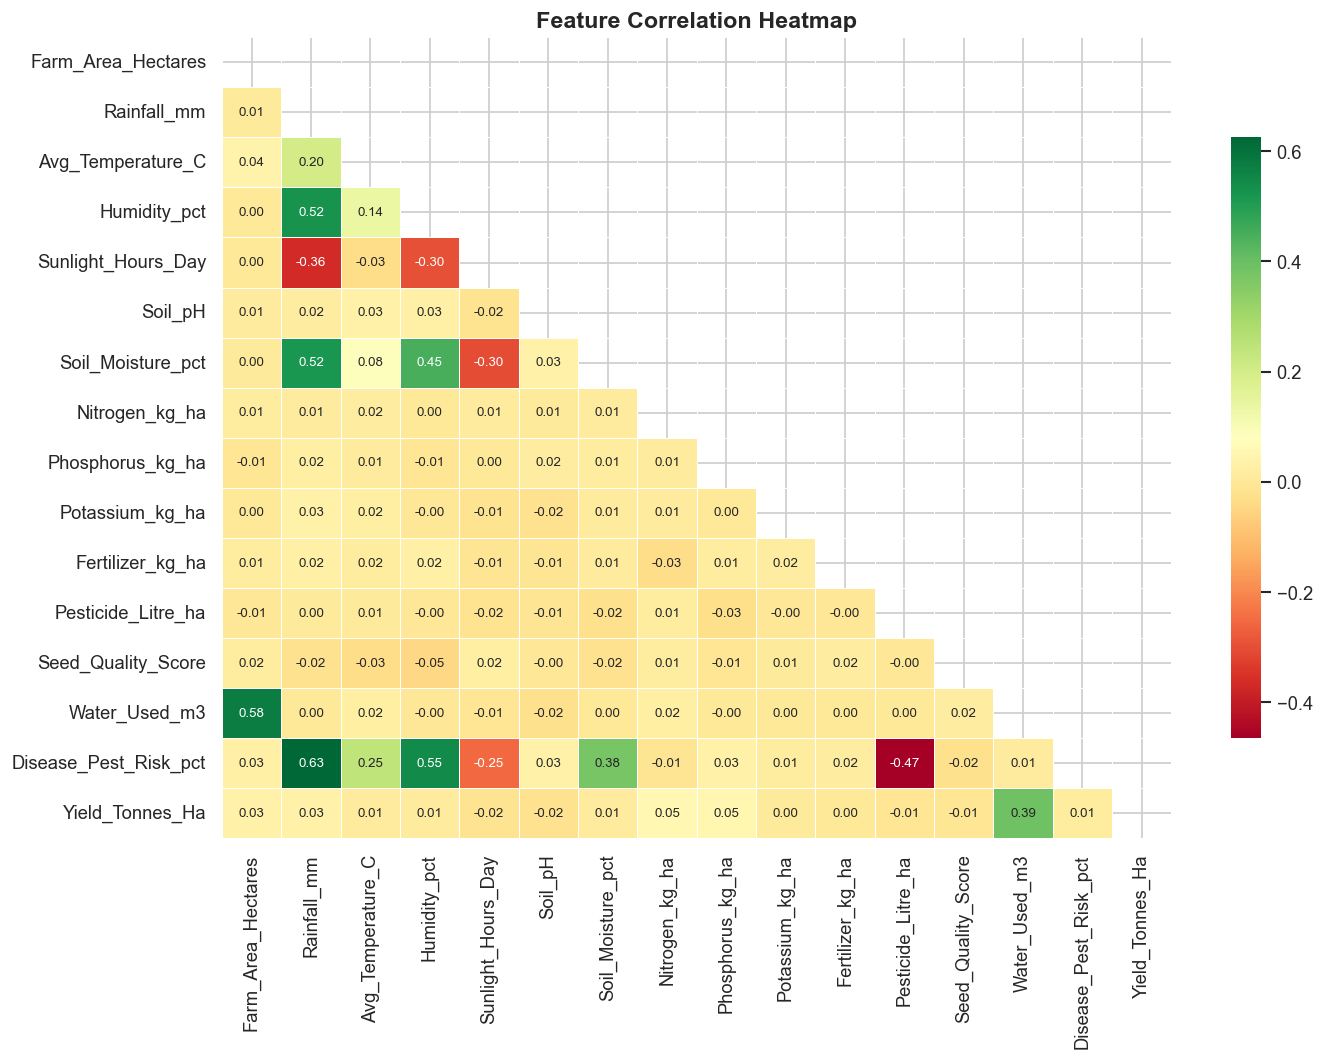

In [12]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr_df = df[NUMERIC_FEATURES + ['Yield_Tonnes_Ha']].corr()
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.75},
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

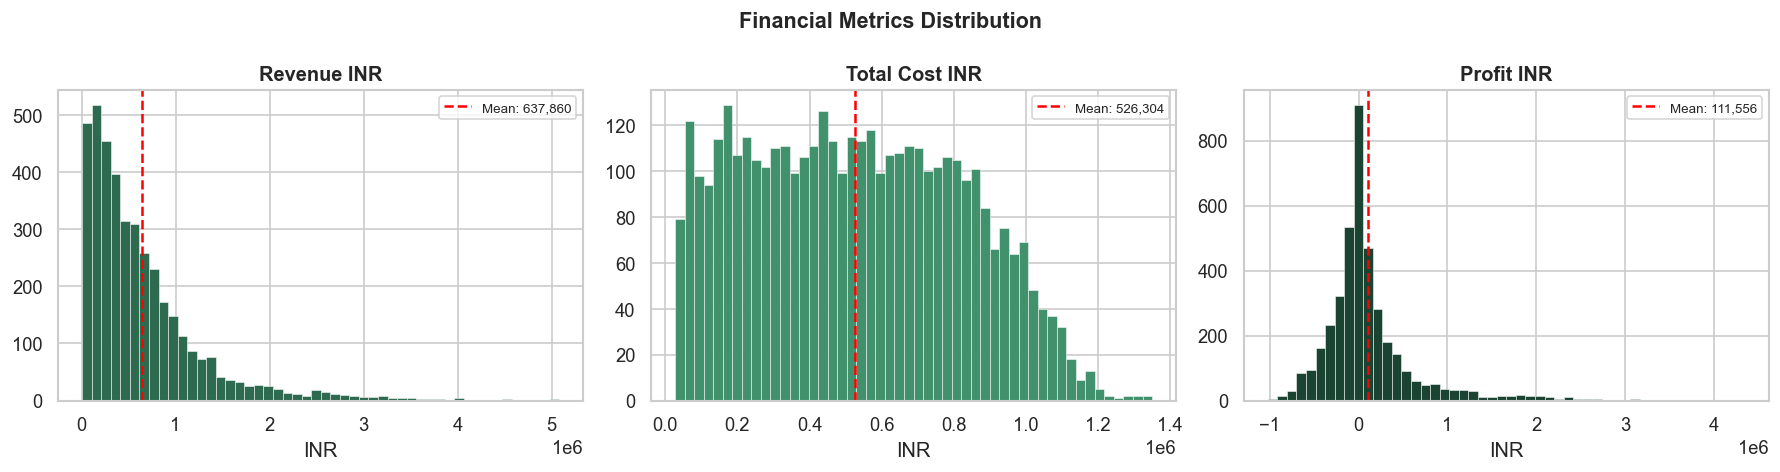

In [13]:
# Financial metrics overview
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR'],
    ['#2d6a4f', '#40916c', '#1b4332']):
    data = df[col].dropna()
    ax.hist(data, bins=50, color=color, edgecolor='white', linewidth=0.3)
    ax.set_title(col.replace('_',' '), fontweight='bold')
    ax.set_xlabel('INR')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():,.0f}')
    ax.legend(fontsize=8)

plt.suptitle('Financial Metrics Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Feature Engineering

In [14]:
CATEGORICAL_COLS = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
TARGET = 'Yield_Tonnes_Ha'

# Drop rows with NaN in features or target
df_clean = df.dropna(subset=[TARGET] + NUMERIC_FEATURES + CATEGORICAL_COLS).reset_index(drop=True)
print(f'Original rows : {len(df)}')
print(f'After dropna  : {len(df_clean)}')
print(f'Rows removed  : {len(df) - len(df_clean)}')

Original rows : 4000
After dropna  : 3880
Rows removed  : 120


In [15]:
# Label encode categorical columns
label_encoders = {}
df_enc = df_clean.copy()

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    label_encoders[col] = le
    print(f'{col:22s} -> {len(le.classes_)} classes: {list(le.classes_)}')

State                  -> 8 classes: ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
District               -> 10 classes: ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
Crop                   -> 8 classes: ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season                 -> 3 classes: ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method      -> 4 classes: ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


In [16]:
# Build feature matrix & target vector
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_COLS

X = df_enc[FEATURE_COLS]
y = df_enc[TARGET]

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'\nFeatures ({len(FEATURE_COLS)}):')
for i, f in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {f}')

X shape : (3880, 20)
y shape : (3880,)

Features (20):
   1. Farm_Area_Hectares
   2. Rainfall_mm
   3. Avg_Temperature_C
   4. Humidity_pct
   5. Sunlight_Hours_Day
   6. Soil_pH
   7. Soil_Moisture_pct
   8. Nitrogen_kg_ha
   9. Phosphorus_kg_ha
  10. Potassium_kg_ha
  11. Fertilizer_kg_ha
  12. Pesticide_Litre_ha
  13. Seed_Quality_Score
  14. Water_Used_m3
  15. Disease_Pest_Risk_pct
  16. State
  17. District
  18. Crop
  19. Season
  20. Irrigation_Method


In [17]:
# Train / Test split — 80 / 20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape[0]} rows  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test  : {X_test.shape[0]}  rows  ({X_test.shape[0]/len(X)*100:.1f}%)')

Train : 3104 rows  (80.0%)
Test  : 776  rows  (20.0%)


## 5. Model Training

In [18]:
models = {
    'RandomForest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'Ridge':            Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))]),
    'LinearRegression': Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
}

print('Training models...')
results = {}

for name, model in models.items():
    print(f'  {name}...', end=' ', flush=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results[name] = {'RMSE': round(rmse,4), 'MAE': round(mae,4),
                     'R2':   round(r2,4),   'CV_R2': round(cv,4)}
    print(f'done  RMSE={rmse:.4f}  R2={r2:.4f}')

print('\nAll models trained.')

Training models...
  RandomForest... 

done  RMSE=2.1907  R2=0.9646
  GradientBoosting... 

done  RMSE=2.4207  R2=0.9567
  Ridge... 

done  RMSE=10.7081  R2=0.1532
  LinearRegression... 

done  RMSE=10.7087  R2=0.1531

All models trained.


## 6. Model Evaluation & Comparison

In [19]:
# Results table
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'RMSE', 'MAE', 'R2', 'CV_R2']
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
results_df.index += 1

print('Model Performance Summary (sorted by R²):')
print(results_df.to_string())

best_name = results_df.iloc[0]['Model']
print(f'\nBest model: {best_name}')

Model Performance Summary (sorted by R²):
              Model     RMSE     MAE      R2   CV_R2
1      RandomForest   2.1907  0.6172  0.9646  0.9641
2  GradientBoosting   2.4207  0.9418  0.9567  0.9530
3             Ridge  10.7081  5.8911  0.1532  0.2309
4  LinearRegression  10.7087  5.8923  0.1531  0.2308

Best model: RandomForest


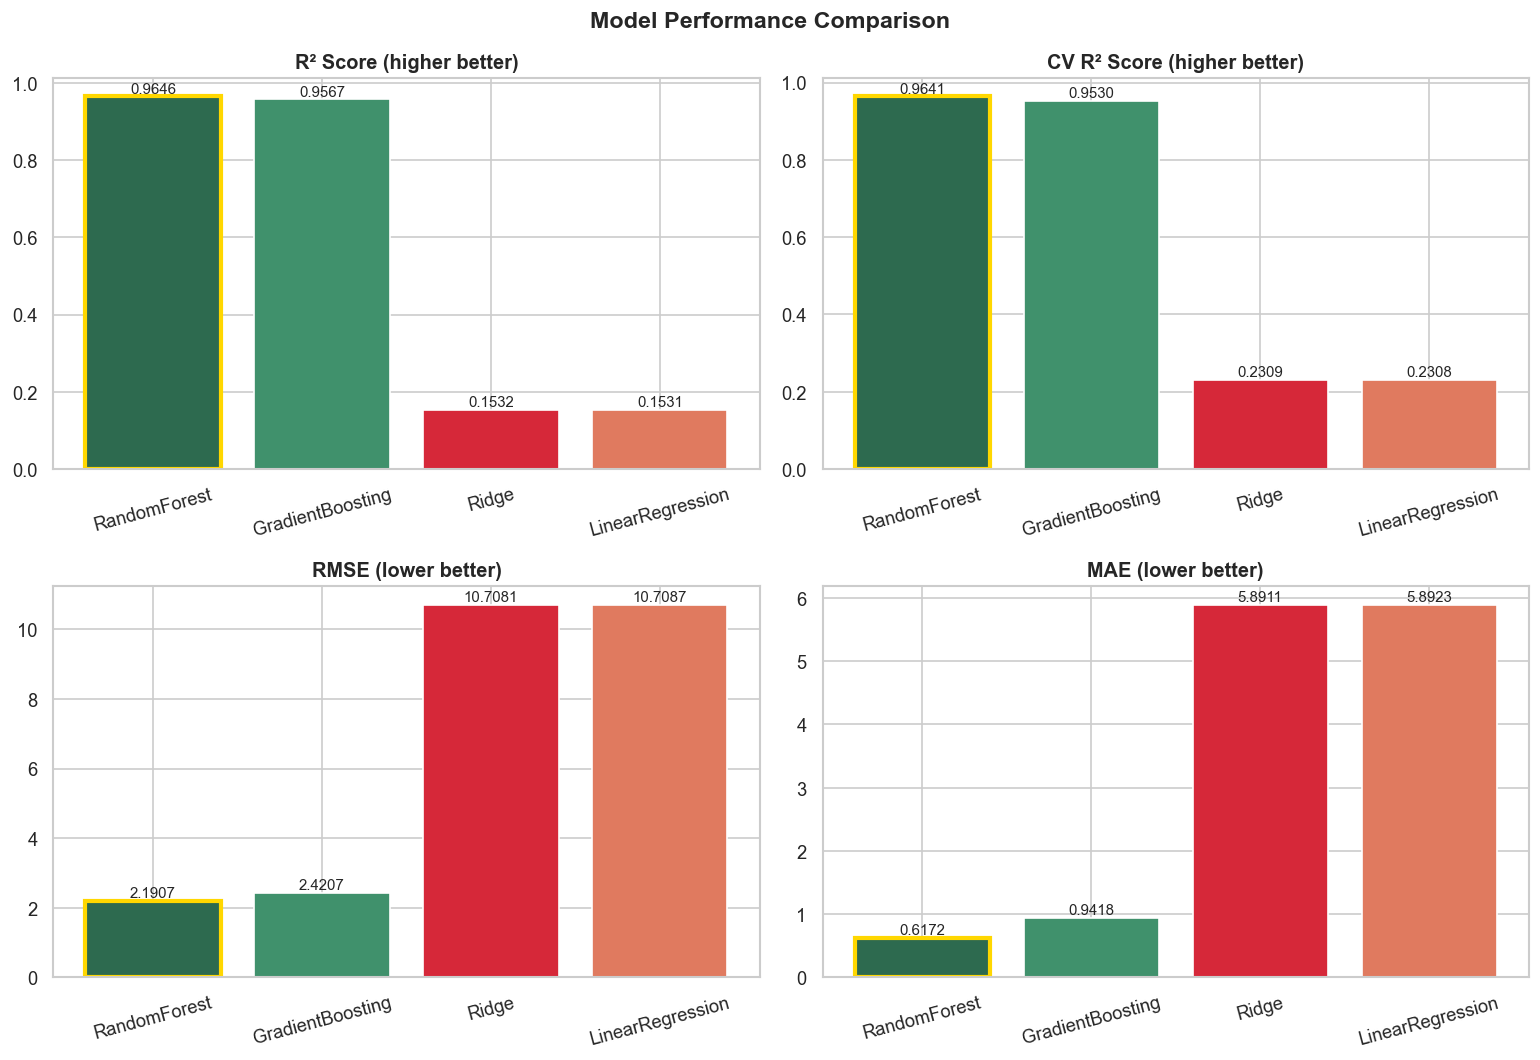

In [20]:
# Model comparison bar charts
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
model_names = list(results.keys())
palette = ['#2d6a4f', '#40916c', '#d62839', '#e07a5f']

metrics_to_plot = [
    ('R2',    'R² Score (higher better)',    axes[0,0]),
    ('CV_R2', 'CV R² Score (higher better)', axes[0,1]),
    ('RMSE',  'RMSE (lower better)',         axes[1,0]),
    ('MAE',   'MAE (lower better)',          axes[1,1]),
]

for metric, title, ax in metrics_to_plot:
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=palette, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{v:.4f}', ha='center', fontsize=9)
    # Highlight best
    best_idx = vals.index(max(vals) if 'lower' not in title else min(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

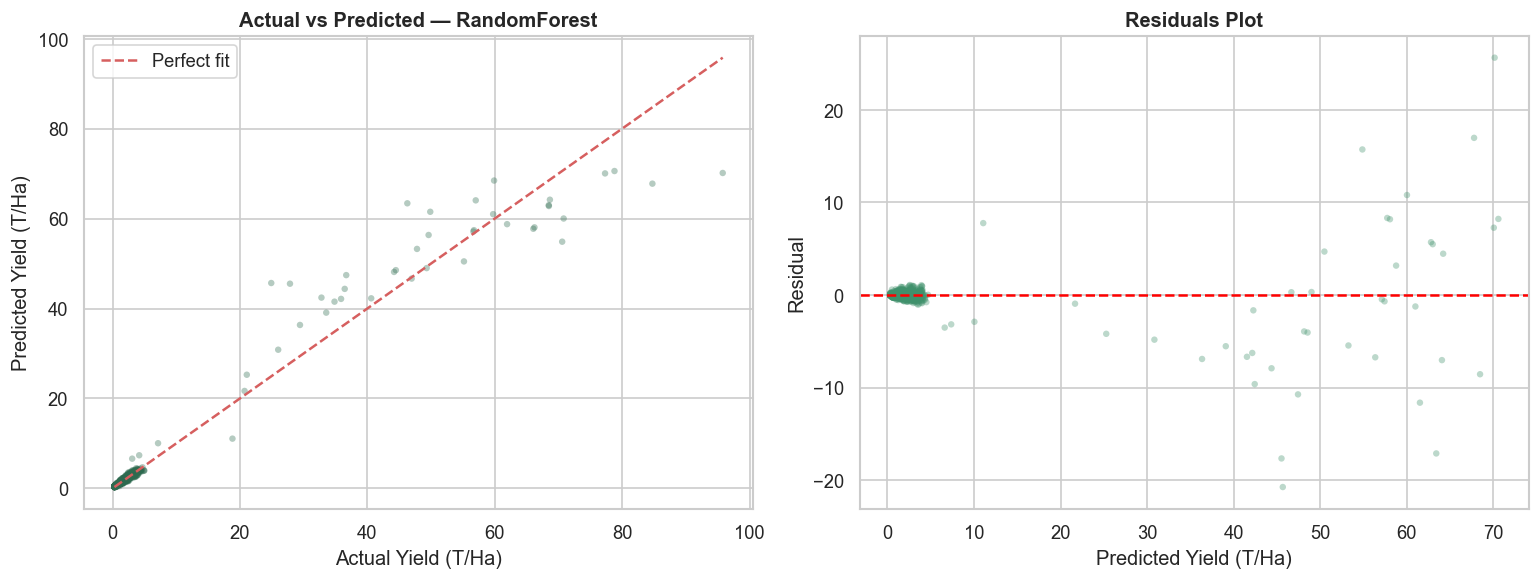

R²   = 0.9646
RMSE = 2.1907
MAE  = 0.6172


In [21]:
# Actual vs Predicted — Best Model
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_test, y_pred_best, alpha=0.35, s=15, color='#2d6a4f', edgecolors='none')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Yield (T/Ha)')
axes[0].set_ylabel('Predicted Yield (T/Ha)')
axes[0].set_title(f'Actual vs Predicted — {best_name}', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.35, s=15, color='#40916c', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Yield (T/Ha)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals Plot', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'R²   = {r2_score(y_test, y_pred_best):.4f}')
print(f'RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}')
print(f'MAE  = {mean_absolute_error(y_test, y_pred_best):.4f}')

RandomForest            CV scores: [0.9615 0.9648 0.9696 0.9525 0.9722]  mean=0.9641  std=0.0069


GradientBoosting        CV scores: [0.9494 0.9617 0.9548 0.9473 0.952 ]  mean=0.9530  std=0.0050
Ridge                   CV scores: [0.1943 0.2522 0.1712 0.2903 0.2462]  mean=0.2309  std=0.0427
LinearRegression        CV scores: [0.1943 0.2522 0.1712 0.2904 0.2462]  mean=0.2308  std=0.0427


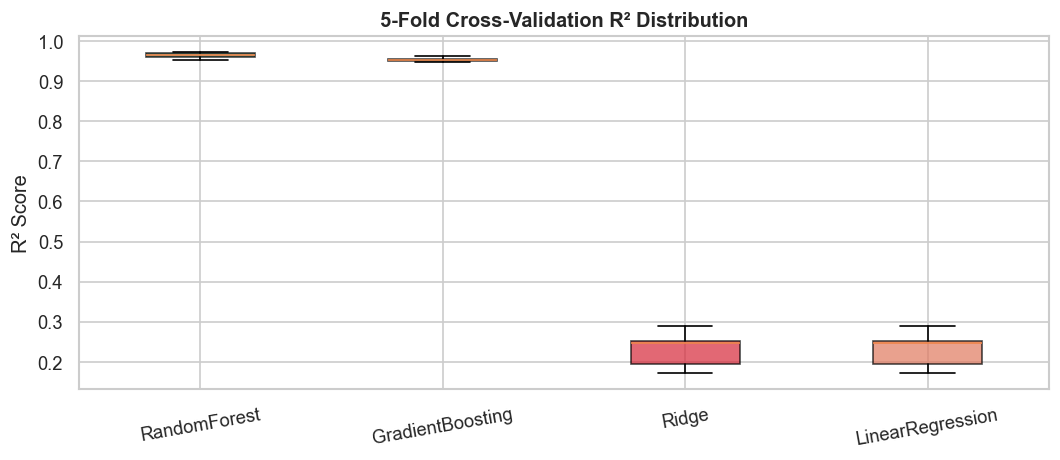

In [22]:
# Cross-validation scores distribution
fig, ax = plt.subplots(figsize=(9, 4))

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f'{name:22s}  CV scores: {scores.round(4)}  mean={scores.mean():.4f}  std={scores.std():.4f}')

bp = ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('R² Score')
ax.set_title('5-Fold Cross-Validation R² Distribution', fontweight='bold')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()

## 7. Feature Importance

In [23]:
# RandomForest feature importances
rf_model = models['RandomForest']
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 10 Features by Importance:')
print(feat_df.head(10).to_string(index=False))

Top 10 Features by Importance:
              Feature  Importance
                 Crop    0.813563
              Soil_pH    0.126585
          Rainfall_mm    0.022687
       Nitrogen_kg_ha    0.005856
    Avg_Temperature_C    0.005578
Disease_Pest_Risk_pct    0.002777
    Irrigation_Method    0.002369
     Fertilizer_kg_ha    0.002285
   Pesticide_Litre_ha    0.002208
   Farm_Area_Hectares    0.002144


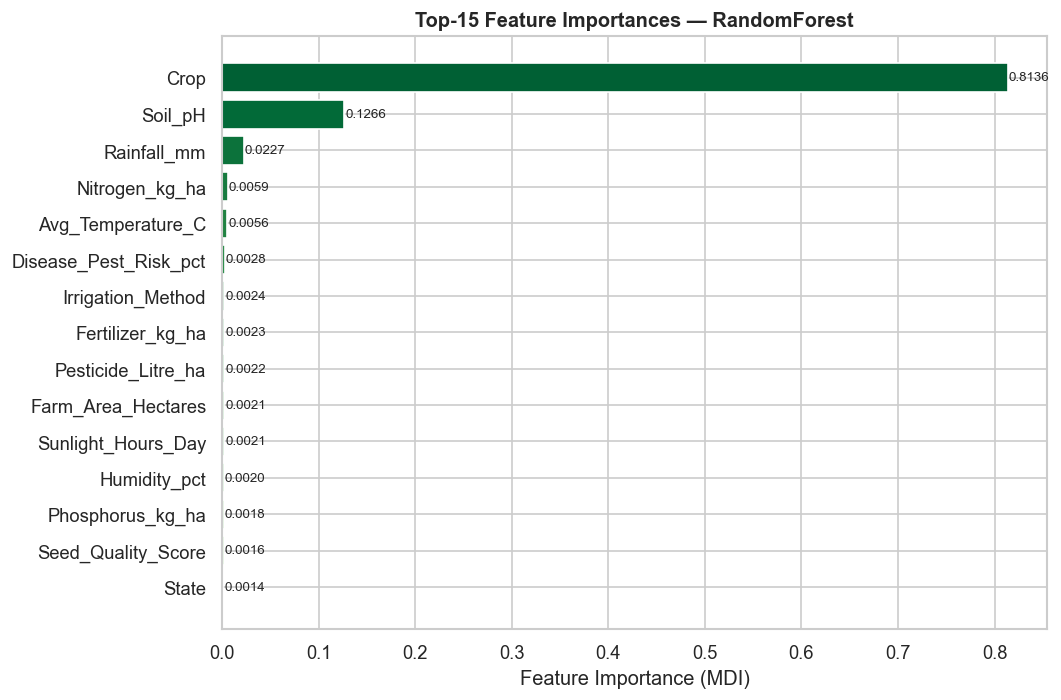

In [24]:
# Feature importance plot
top15 = feat_df.head(15).sort_values('Importance')

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.YlGn(np.linspace(0.4, 0.9, len(top15)))
bars = ax.barh(top15['Feature'], top15['Importance'], color=colors)
ax.set_xlabel('Feature Importance (MDI)')
ax.set_title('Top-15 Feature Importances — RandomForest', fontweight='bold')
for bar, v in zip(bars, top15['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

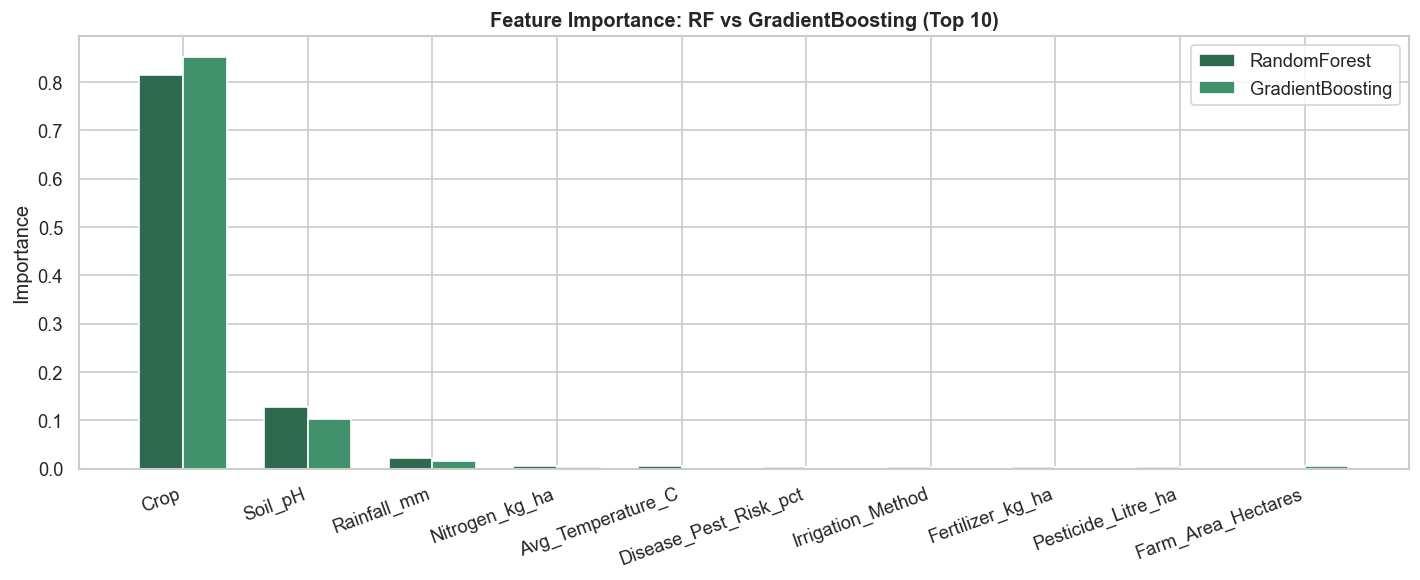

In [25]:
# GradientBoosting feature importances comparison
gb_model = models['GradientBoosting']
gb_imp = gb_model.feature_importances_

compare_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'RandomForest': importances,
    'GradientBoosting': gb_imp
}).sort_values('RandomForest', ascending=False).head(10)

x = np.arange(len(compare_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, compare_df['RandomForest'],   width, label='RandomForest',     color='#2d6a4f')
ax.bar(x + width/2, compare_df['GradientBoosting'],width, label='GradientBoosting', color='#40916c')
ax.set_xticks(x)
ax.set_xticklabels(compare_df['Feature'], rotation=20, ha='right')
ax.set_ylabel('Importance')
ax.set_title('Feature Importance: RF vs GradientBoosting (Top 10)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Additional Visualisations

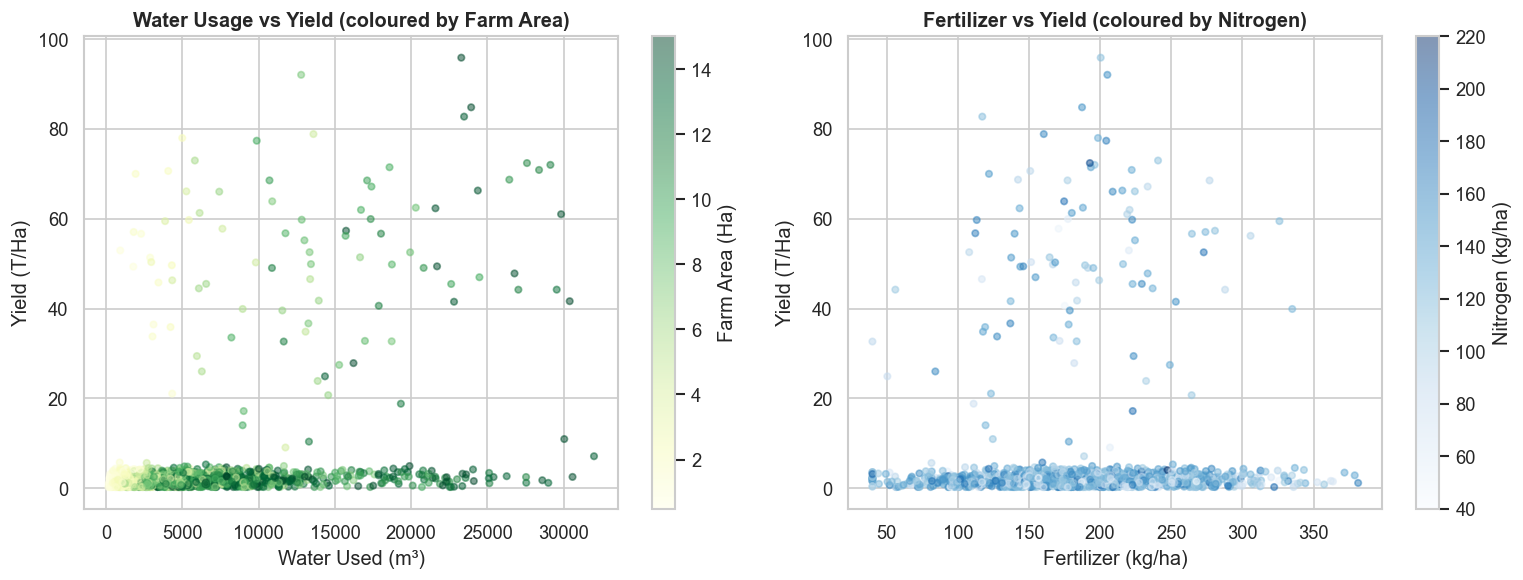

In [26]:
# Water Efficiency vs Yield
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter_df = df_clean.sample(1500, random_state=42)

sc = axes[0].scatter(scatter_df['Water_Used_m3'], scatter_df['Yield_Tonnes_Ha'],
    c=scatter_df['Farm_Area_Hectares'], cmap='YlGn', alpha=0.5, s=15)
plt.colorbar(sc, ax=axes[0], label='Farm Area (Ha)')
axes[0].set_xlabel('Water Used (m³)')
axes[0].set_ylabel('Yield (T/Ha)')
axes[0].set_title('Water Usage vs Yield (coloured by Farm Area)', fontweight='bold')

# Fertilizer vs Yield
sc2 = axes[1].scatter(scatter_df['Fertilizer_kg_ha'], scatter_df['Yield_Tonnes_Ha'],
    c=scatter_df['Nitrogen_kg_ha'], cmap='Blues', alpha=0.5, s=15)
plt.colorbar(sc2, ax=axes[1], label='Nitrogen (kg/ha)')
axes[1].set_xlabel('Fertilizer (kg/ha)')
axes[1].set_ylabel('Yield (T/Ha)')
axes[1].set_title('Fertilizer vs Yield (coloured by Nitrogen)', fontweight='bold')

plt.tight_layout()
plt.show()

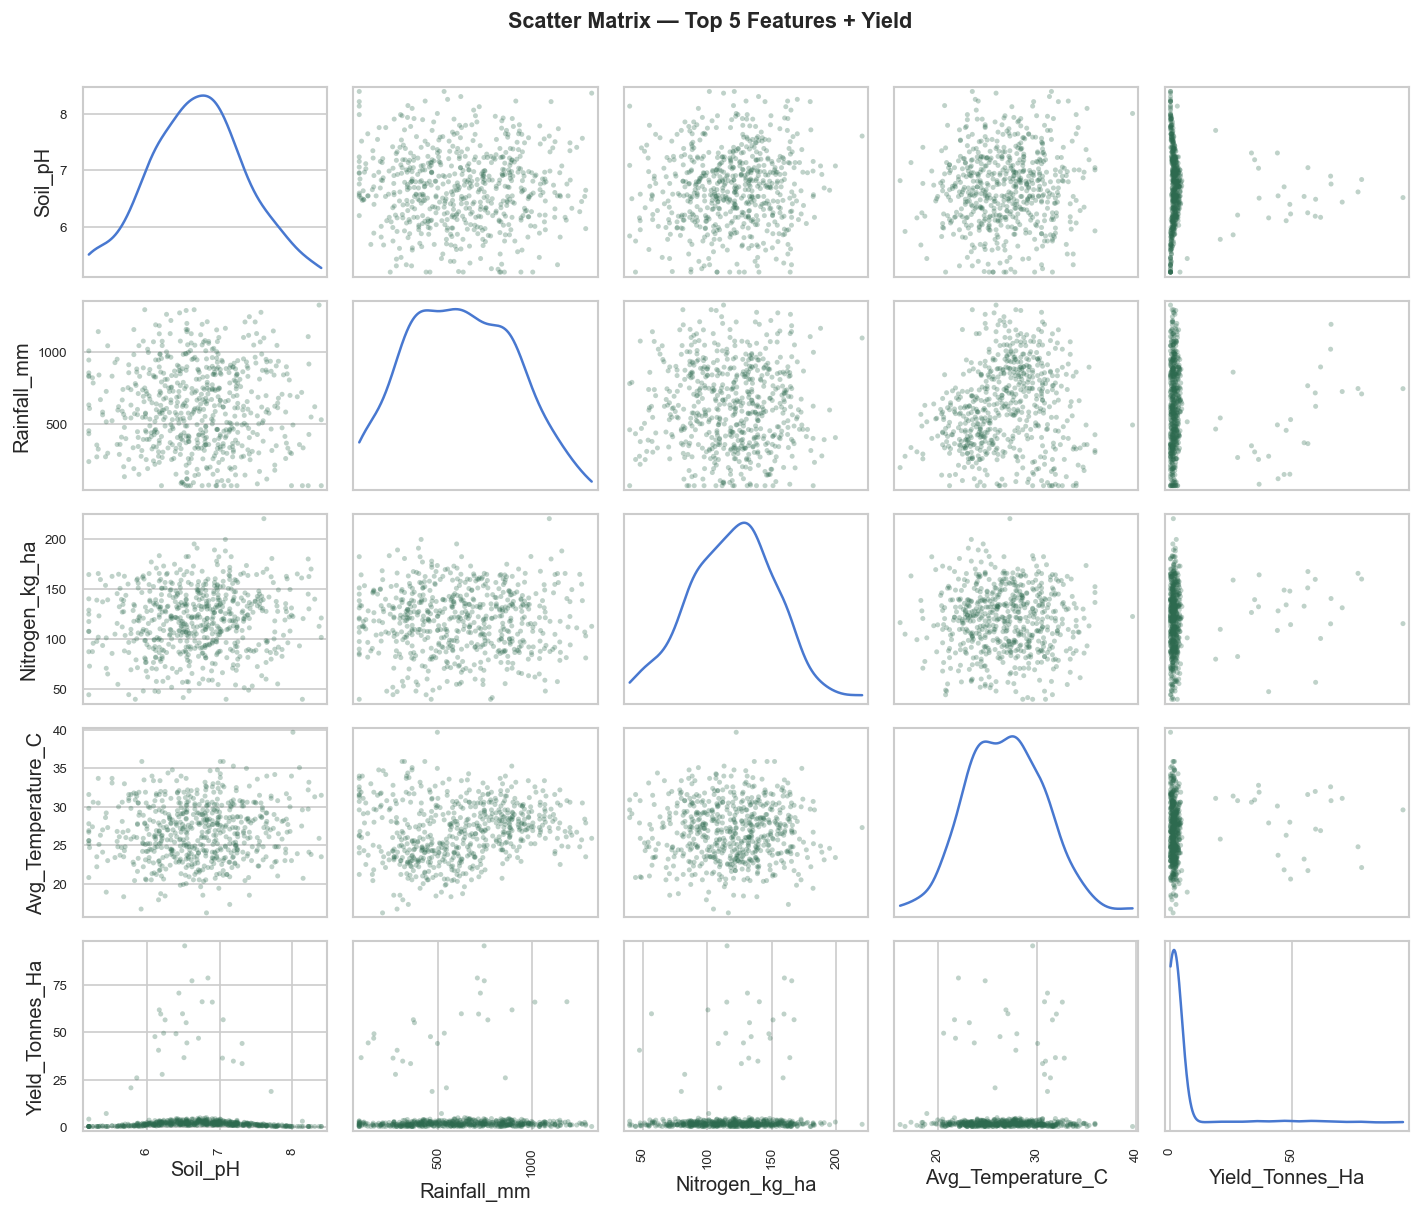

In [27]:
# Scatter matrix of top features
from pandas.plotting import scatter_matrix
top5 = feat_df.head(5)['Feature'].tolist()
pair_df = df_clean[top5 + [TARGET]].sample(600, random_state=42)

axs = scatter_matrix(pair_df, alpha=0.3, figsize=(12, 10),
                     diagonal='kde', color='#2d6a4f')
plt.suptitle('Scatter Matrix — Top 5 Features + Yield', y=1.01,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

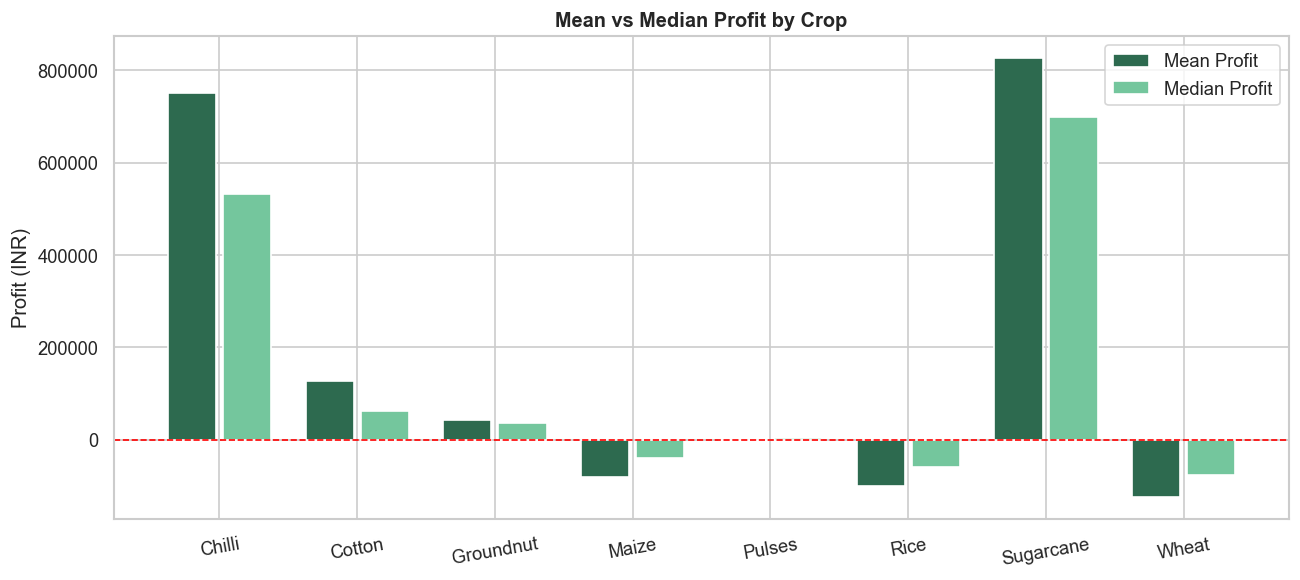

In [28]:
# Profit distribution by Crop
fig, ax = plt.subplots(figsize=(11, 5))
crop_profit = df_clean.groupby('Crop')['Profit_INR'].agg(['mean','median']).reset_index()
x = np.arange(len(crop_profit))
ax.bar(x - 0.2, crop_profit['mean'],   0.35, label='Mean Profit',   color='#2d6a4f')
ax.bar(x + 0.2, crop_profit['median'], 0.35, label='Median Profit', color='#74c69d')
ax.set_xticks(x)
ax.set_xticklabels(crop_profit['Crop'], rotation=10)
ax.set_ylabel('Profit (INR)')
ax.set_title('Mean vs Median Profit by Crop', fontweight='bold')
ax.axhline(0, color='red', linestyle='--', lw=1)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Save Model Artifacts

In [29]:
# Determine model save directory
MODEL_DIR = 'agri_yield_predictor/models'
if not os.path.exists('agri_yield_predictor'):
    MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Save best model and encoders
joblib.dump(best_model, os.path.join(MODEL_DIR, 'best_model.pkl'))
joblib.dump(label_encoders, os.path.join(MODEL_DIR, 'label_encoders.pkl'))

# Save metadata
meta = {
    'best_model':     best_name,
    'feature_cols':   FEATURE_COLS,
    'categorical_cols': CATEGORICAL_COLS,
    'numeric_features': NUMERIC_FEATURES,
    'target':         TARGET,
    'metrics':        results,
    'unique_values':  {col: sorted(df_clean[col].unique().tolist())
                       for col in CATEGORICAL_COLS}
}
with open(os.path.join(MODEL_DIR, 'model_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved to {MODEL_DIR}/')
print(f'  best_model.pkl     ({os.path.getsize(os.path.join(MODEL_DIR,"best_model.pkl"))/1e6:.1f} MB)')
print(f'  label_encoders.pkl')
print(f'  model_meta.json')

Saved to models/
  best_model.pkl     (52.2 MB)
  label_encoders.pkl
  model_meta.json


## 10. Sample Predictions

In [30]:
def predict_yield(crop, season, state, district, irrigation,
                  farm_area, rainfall, temperature, humidity,
                  sunlight, soil_ph, soil_moisture, nitrogen,
                  phosphorus, potassium, fertilizer, pesticide,
                  seed_quality, water_used, disease_risk):
    """Predict yield for a single farm record."""
    row = {
        'Farm_Area_Hectares':    farm_area,
        'Rainfall_mm':           rainfall,
        'Avg_Temperature_C':     temperature,
        'Humidity_pct':          humidity,
        'Sunlight_Hours_Day':    sunlight,
        'Soil_pH':               soil_ph,
        'Soil_Moisture_pct':     soil_moisture,
        'Nitrogen_kg_ha':        nitrogen,
        'Phosphorus_kg_ha':      phosphorus,
        'Potassium_kg_ha':       potassium,
        'Fertilizer_kg_ha':      fertilizer,
        'Pesticide_Litre_ha':    pesticide,
        'Seed_Quality_Score':    seed_quality,
        'Water_Used_m3':         water_used,
        'Disease_Pest_Risk_pct': disease_risk,
        'State':       int(label_encoders['State'].transform([state])[0]),
        'District':    int(label_encoders['District'].transform([district])[0]),
        'Crop':        int(label_encoders['Crop'].transform([crop])[0]),
        'Season':      int(label_encoders['Season'].transform([season])[0]),
        'Irrigation_Method': int(label_encoders['Irrigation_Method'].transform([irrigation])[0]),
    }
    X_input = pd.DataFrame([row], columns=FEATURE_COLS)
    prediction = best_model.predict(X_input)[0]
    return round(prediction, 4)

print('predict_yield() function ready')

predict_yield() function ready


In [31]:
# --- Sample predictions ---
samples = [
    dict(crop='Rice',     season='Kharif', state='Telangana',     district='Warangal',
         irrigation='Drip',      farm_area=5.0,  rainfall=700,  temperature=29, humidity=70,
         sunlight=7,  soil_ph=6.2, soil_moisture=28, nitrogen=120, phosphorus=55,
         potassium=110, fertilizer=180, pesticide=5,   seed_quality=0.9,
         water_used=3000, disease_risk=35),
    dict(crop='Wheat',    season='Rabi',   state='Punjab',        district='Ludhiana',
         irrigation='Sprinkler',  farm_area=8.0,  rainfall=400,  temperature=22, humidity=55,
         sunlight=9,  soil_ph=7.0, soil_moisture=20, nitrogen=100, phosphorus=60,
         potassium=90,  fertilizer=160, pesticide=4,   seed_quality=0.85,
         water_used=2000, disease_risk=25),
    dict(crop='Maize',    season='Zaid',   state='Karnataka',     district='Raichur',
         irrigation='Flood',      farm_area=6.0,  rainfall=550,  temperature=32, humidity=60,
         sunlight=8,  soil_ph=6.5, soil_moisture=22, nitrogen=110, phosphorus=50,
         potassium=100, fertilizer=200, pesticide=6,   seed_quality=0.88,
         water_used=3500, disease_risk=40),
    dict(crop='Cotton',   season='Kharif', state='Gujarat',       district='Rajkot',
         irrigation='Rainfed',    farm_area=10.0, rainfall=600,  temperature=33, humidity=50,
         sunlight=8,  soil_ph=7.2, soil_moisture=18, nitrogen=90,  phosphorus=45,
         potassium=80,  fertilizer=150, pesticide=7,   seed_quality=0.82,
         water_used=1500, disease_risk=50),
    dict(crop='Sugarcane',season='Kharif', state='Maharashtra',   district='Nashik',
         irrigation='Drip',      farm_area=7.0,  rainfall=800,  temperature=28, humidity=75,
         sunlight=6,  soil_ph=6.8, soil_moisture=35, nitrogen=150, phosphorus=70,
         potassium=130, fertilizer=250, pesticide=8,   seed_quality=0.95,
         water_used=5000, disease_risk=30),
]

print(f'{"Crop":<12} {"Season":<8} {"State":<18} {"Predicted Yield":>18}')
print('-' * 60)
for s in samples:
    y_pred = predict_yield(**s)
    print(f"{s['crop']:<12} {s['season']:<8} {s['state']:<18} {y_pred:>14.4f} T/Ha")

Crop         Season   State                 Predicted Yield
------------------------------------------------------------
Rice         Kharif   Telangana                  2.6962 T/Ha
Wheat        Rabi     Punjab                     2.3715 T/Ha
Maize        Zaid     Karnataka                  3.4829 T/Ha
Cotton       Kharif   Gujarat                    1.2115 T/Ha
Sugarcane    Kharif   Maharashtra               76.8898 T/Ha


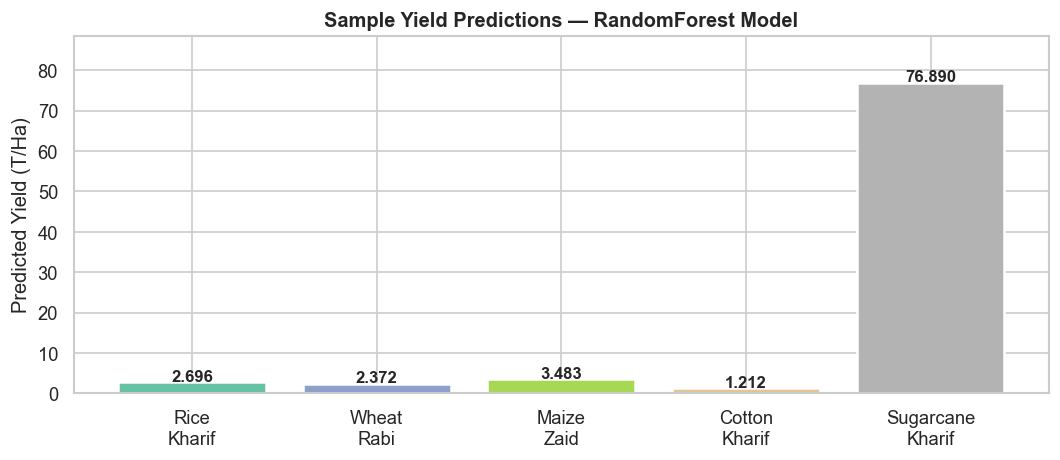

In [32]:
# Visualise sample predictions
preds = []
labels = []
for s in samples:
    preds.append(predict_yield(**s))
    labels.append(f"{s['crop']}\n{s['season']}")

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))
bars = ax.bar(labels, preds, color=colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, preds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Predicted Yield (T/Ha)')
ax.set_title('Sample Yield Predictions — RandomForest Model', fontweight='bold')
ax.set_ylim(0, max(preds) * 1.15)
plt.tight_layout()
plt.show()

In [33]:
# Final summary
print('=' * 55)
print('  AGRICULTURAL YIELD PREDICTOR — PROJECT SUMMARY')
print('=' * 55)
print(f'  Dataset        : {len(df_clean)} clean records, {len(FEATURE_COLS)} features')
print(f'  Target         : Yield_Tonnes_Ha')
print(f'  Best Model     : {best_name}')
print(f'  R² (test)      : {results[best_name]["R2"]}')
print(f'  R² (CV 5-fold) : {results[best_name]["CV_R2"]}')
print(f'  RMSE           : {results[best_name]["RMSE"]}')
print(f'  MAE            : {results[best_name]["MAE"]}')
print('=' * 55)
print('  Flask API  : python app.py')
print('  UI         : http://localhost:5000/')
print('  Dashboard  : http://localhost:5000/dashboard')
print('=' * 55)

  AGRICULTURAL YIELD PREDICTOR — PROJECT SUMMARY
  Dataset        : 3880 clean records, 20 features
  Target         : Yield_Tonnes_Ha
  Best Model     : RandomForest
  R² (test)      : 0.9646
  R² (CV 5-fold) : 0.9641
  RMSE           : 2.1907
  MAE            : 0.6172
  Flask API  : python app.py
  UI         : http://localhost:5000/
  Dashboard  : http://localhost:5000/dashboard
